#***Processing***

In [1]:
!pip install Keras
!pip install vit-keras
!pip install tensorflow-addons
!pip install opendatasets
!pip install tensorflow-hub

import opendatasets as od
import pandas

import os

import keras.preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras import layers
from keras import regularizers, activations
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.callbacks import ModelCheckpoint
from keras.layers import Dense, Dropout, Flatten, Activation, Concatenate, Lambda #....
from keras.layers import Input, Conv2D, MaxPooling2D, GlobalAveragePooling2D, BatchNormalization, ZeroPadding2D #....
from keras.models import Model
from keras.optimizers import Adam
from keras.applications import ResNet50V2
from keras.preprocessing.image import ImageDataGenerator
from vit_keras import vit, utils


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.8/611.8 kB 8.2 MB/s eta 0:00:00


/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/fish 7p.zip"

Archive:  /content/drive/MyDrive/fish 7p.zip
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).jpeg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).jpg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (1).png  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (10).jpg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (11).jpg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (116).jpg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bacterial Red disease (117).jpg  
  inflating: Freshwater Fish Disease Aquaculture in south asia/Test/Bacterial Red disease/Bact

In [ ]:
!pip install patool  ## unzip rar files


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
import os
from patoolib import extract_archive

def unzip_rar_files(folder_path):
    # Get a list of all files in the specified folder
    files = os.listdir(folder_path)

    # Iterate through each file in the folder
    for file in files:
        file_path = os.path.join(folder_path, file)

        # Check if the file is a .rar file
        if file.endswith(".rar"):
            try:
                # Extract the .rar file using patoolib
                extract_archive(file_path, outdir=folder_path)
                print(f"Successfully extracted: {file}")
            except Exception as e:
                print(f"Error extracting {file}: {e}")

# Specify the folder path containing the .rar files
folder_path = "/content/Freshwater Fish Disease Aquaculture in south asia/Train"

# Call the function to unzip .rar files in the specified folder
unzip_rar_files(folder_path)


In [ ]:

base_dir = '/content/Freshwater Fish Disease Aquaculture in south asia/Train'

In [ ]:
import os

def get_folder_names(directory_path):
    # Initialize an empty list to store folder names
    folder_names = []

    # Iterate over items in the specified directory
    for item in os.listdir(directory_path):
        item_path = os.path.join(directory_path, item)

        # Check if the item is a directory
        if os.path.isdir(item_path):
          if item != '.ipynb_checkpoints':
            folder_names.append(item)

    return folder_names

# Specify the directory path for which you want to fetch folder names
directory_path = "/content/Freshwater Fish Disease Aquaculture in south asia/Train"

# Call the function to get folder names in the specified directory
folders = get_folder_names(directory_path)

# Print the list of folder names
print("Folder Names:", folders)


Folder Names: ['Bacterial diseases - Aeromoniasis', 'Viral diseases White tail disease', 'Bacterial gill disease', 'Parasitic diseases', 'Fungal diseases Saprolegniasis', 'Healthy Fish', 'Bacterial Red disease']


In [ ]:
import os
import cv2

def resize_and_rescale_image(root_directory, output_directory, target_size=(224, 224)):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            for file_name in os.listdir(source_directory):
                # Check if the file is an image
                if file_name.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                    # Construct the input and output paths
                    input_image_path = os.path.join(source_directory, file_name)
                    output_image_path = os.path.join(output_subfolder, file_name)

                    # Read the image
                    image = cv2.imread(input_image_path)

                    # Resize the image
                    resized_image = cv2.resize(image, target_size)

                    # Rescale pixel values to range [0, 1]
                    resized_image = resized_image.astype('float32') / 255.0

                    # Save the resized and rescaled image
                    cv2.imwrite(output_image_path, resized_image * 255)  # Multiplying by 255 to convert back to uint8

                    print("Processed:", input_image_path, "Saved as:", output_image_path)

# Example usage
root_directory = '/content/Freshwater Fish Disease Aquaculture in south asia/Train'
output_directory = '/content/resized_images'  # Provide the path to your output directory
resize_and_rescale_image(root_directory, output_directory)


Processed: /content/Freshwater Fish Disease Aquaculture in south asia/Train/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (47).jpg Saved as: /content/resized_images/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (47).jpg
Processed: /content/Freshwater Fish Disease Aquaculture in south asia/Train/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (172).jpg Saved as: /content/resized_images/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (172).jpg
Processed: /content/Freshwater Fish Disease Aquaculture in south asia/Train/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (57).jpg Saved as: /content/resized_images/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (57).jpg
Processed: /content/Freshwater Fish Disease Aquaculture in south asia/Train/Bacterial diseases - Aeromoniasis/Bacterial diseases - Aeromoniasis (1).jpeg Saved as: /content/resized_images/Bacterial diseases 

In [ ]:
base_dir = '/content/resized_images'

In [ ]:
import os
import cv2
from tqdm import tqdm

def invert_colors(image):
    inverted_image = cv2.bitwise_not(image)
    return inverted_image

def invert_colors_in_subfolders(root_directory, output_directory):
    # Iterate through subfolders
    for subfolder in os.listdir(root_directory):
        subfolder_path = os.path.join(root_directory, subfolder)

        # Check if it's a directory
        if os.path.isdir(subfolder_path):
            # Define source and output directories for the current subfolder
            source_directory = subfolder_path
            output_subfolder = os.path.join(output_directory, subfolder)

            # Create output directory if it doesn't exist
            if not os.path.exists(output_subfolder):
                os.makedirs(output_subfolder)

            # Process images in the current subfolder
            image_files = [f for f in os.listdir(source_directory) if f.endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'))]
            for file_name in tqdm(image_files, desc="Processing " + subfolder):
                # Construct the input and output paths
                input_image_path = os.path.join(source_directory, file_name)
                output_image_path = os.path.join(output_subfolder, file_name)

                # Read the image
                image = cv2.imread(input_image_path)

                # Check if the image is loaded successfully
                if image is not None:
                    # Perform color inversion
                    inverted_image = invert_colors(image)

                    # Save the inverted image
                    cv2.imwrite(output_image_path, inverted_image)
                else:
                    print("Error: Could not open or find the image:", input_image_path)

# Example usage
root_directory = '/content/resized_images'
output_directory = '/content/inverted_images3'  # Provide the path to your output directory
invert_colors_in_subfolders(root_directory, output_directory)


Processing Bacterial Red disease: 100%|██████████| 250/250 [00:00<00:00, 405.14it/s]


In [ ]:
base_dir = '/content/inverted_images3'

In [ ]:
import os
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image

def augment_images(source_directory, output_directory, target_count=2000):
    # Create an ImageDataGenerator
    datagen = ImageDataGenerator(
    featurewise_center=True,
    samplewise_center=True,
    featurewise_std_normalization=True,
    samplewise_std_normalization=True,
    zca_whitening=True,
    zca_epsilon=1e-06,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=None,
    shear_range=0.2,
    zoom_range=0.1,
    channel_shift_range=0.2,
    fill_mode='nearest',
    cval=0.2,
    horizontal_flip=True,
    vertical_flip=True,
)

    # Ensure the destination directory exists; create it if necessary
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)

    # Get the list of files in the source directory
    image_files = [f for f in os.listdir(source_directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Calculate the number of additional images needed
    existing_images = len(image_files)
    images_per_original = max(1, target_count // existing_images)

    # Augment images until the target count is reached
    for filename in tqdm(image_files, desc="Augmenting images"):
        img_path = os.path.join(source_directory, filename)
        img = image.load_img(img_path)
        img_array = image.img_to_array(img)
        img_array = img_array.reshape((1,) + img_array.shape)

        # Generate augmented images
        i = 0
        for batch in datagen.flow(img_array, batch_size=1, save_to_dir=output_directory, save_prefix='aug', save_format='jpg'):
            i += 1
            if i >= images_per_original:
                break

    # Remove excess images from the output directory
    output_images = os.listdir(output_directory)
    for i in range(len(output_images) - target_count):
        os.remove(os.path.join(output_directory, output_images[i]))

    print(f"Augmentation complete. Total images in '{output_directory}': {len(os.listdir(output_directory))}")

import os

# Specify the root directory containing subfolders
root_directory = base_dir

# Iterate through subfolders
for subfolder in os.listdir(root_directory):
    subfolder_path = os.path.join(root_directory, subfolder)

    # Check if it's a directory
    if os.path.isdir(subfolder_path):
        # Define source and output directories for the current subfolder
        source_directory = subfolder_path
        output_directory = os.path.join('/content/augmented', subfolder)

        # Call the augment_images function for the current subfolder
        augment_images(source_directory, output_directory, target_count=2000)

/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1451: UserWarning: This ImageDataGenerator specifies `zca_whitening` which overrides setting of`featurewise_std_normalization`.
  warnings.warn(
Augmenting images:   0%|          | 0/250 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1862: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/preprocessing/image.py:1885: UserWarning: This ImageDataGenerator specifies `zca_whitening`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(
Augmenting images: 100%|██████████| 250/250 [00:53<00:00,  4.71it/s]


Augmentation complete. Total images in '/content/augmented/Bacterial diseases - Aeromoniasis': 1818


Augmenting images: 100%|██████████| 247/247 [00:26<00:00,  9.24it/s]


Augmentation complete. Total images in '/content/augmented/Viral diseases White tail disease': 1795


Augmenting images: 100%|██████████| 250/250 [00:26<00:00,  9.38it/s]


...

Augmentation complete. Total images in '/content/augmented/Fungal diseases Saprolegniasis': 1826


Augmenting images: 100%|██████████| 250/250 [00:28<00:00,  8.70it/s]


Augmentation complete. Total images in '/content/augmented/Healthy Fish': 1803


Augmenting images: 100%|██████████| 250/250 [00:27<00:00,  9.24it/s]

Augmentation complete. Total images in '/content/augmented/Bacterial Red disease': 1819


In [ ]:
import os
import cv2
import numpy as np

# Function to detect outliers using IQR method
def detect_outliers_iqr(data, threshold=1.5):
    q25, q75 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q75 - q25
    cut_off = iqr * threshold
    lower, upper = q25 - cut_off, q75 + cut_off
    outliers = [x for x in data if x < lower or x > upper]
    return outliers

# Function to handle outliers in an image
def handle_outliers(image):
    # Convert the image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Flatten the image into a 1D array
    flattened_image = gray_image.flatten()
    # Detect outliers in the flattened image
    outliers = detect_outliers_iqr(flattened_image)
    # Replace outliers with median value
    median_value = np.median(flattened_image)
    cleaned_image = np.where(np.isin(flattened_image, outliers), median_value, flattened_image)
    # Reshape the flattened image back to its original shape
    cleaned_image = cleaned_image.reshape(gray_image.shape)
    return cleaned_image

# Root directory
root_dir = "/content/augmented"

# Iterate through each subfolder
for subdir in os.listdir(root_dir):
    subdir_path = os.path.join(root_dir, subdir)
    if os.path.isdir(subdir_path):
        print("Processing subfolder:", subdir)
        # Iterate through each file in the subfolder
        for file_name in os.listdir(subdir_path):
            file_path = os.path.join(subdir_path, file_name)
            if file_name.endswith(('.jpg', '.jpeg', '.png')):
                print("Processing file:", file_name)
                # Load the image
                image = cv2.imread(file_path)
                # Handling outliers
                cleaned_image = handle_outliers(image)
                # Save the cleaned image
                cleaned_file_path = os.path.join(subdir_path, "cleaned_" + file_name)
                cv2.imwrite(cleaned_file_path, cleaned_image)
                print("Cleaned image saved at:", cleaned_file_path)


Streaming output truncated to the last 5000 lines.
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_1710.jpg
Processing file: aug_0_4408.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_4408.jpg
Processing file: aug_0_3614.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_3614.jpg
Processing file: aug_0_9799.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_9799.jpg
Processing file: aug_0_7133.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_7133.jpg
Processing file: aug_0_120.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_120.jpg
Processing file: aug_0_7889.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_7889.jpg
Processing file: aug_0_6169.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned_aug_0_6169.jpg
Processing file: aug_0_7445.jpg
Cleaned image saved at: /content/augmented/Healthy Fish/cleaned

In [ ]:
len(folders)

7

In [ ]:
base_dir = '/content/augmented'

In [ ]:
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)

val_dir = os.path.join(base_dir, 'val')
os.makedirs(val_dir, exist_ok=True)

test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [ ]:

import shutil

# List of class folder names
class_folders = folders
# Split ratios (adjust these as needed)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for folder in class_folders:
    source_folder = os.path.join(base_dir, folder)
    train_dest = os.path.join(train_dir, folder)
    val_dest = os.path.join(val_dir, folder)
    test_dest = os.path.join(test_dir, folder)

    os.makedirs(train_dest, exist_ok=True)
    os.makedirs(val_dest, exist_ok=True)
    os.makedirs(test_dest, exist_ok=True)

    filenames = os.listdir(source_folder)
    num_files = len(filenames)

    num_train = int(num_files * train_ratio)
    num_val = int(num_files * val_ratio)

    train_files = filenames[:num_train]
    val_files = filenames[num_train:num_train + num_val]
    test_files = filenames[num_train + num_val:]

    for file in train_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(train_dest, file)
        shutil.copy(src_path, dest_path)

    for file in val_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(val_dest, file)
        shutil.copy(src_path, dest_path)

    for file in test_files:
        src_path = os.path.join(source_folder, file)
        dest_path = os.path.join(test_dest, file)
        shutil.copy(src_path, dest_path)



In [ ]:

size = 224

batch_size = 64
target_size = (size,size)  # Adjust as needed

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size)

val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=target_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

Found 17718 images belonging to 7 classes.
Found 3793 images belonging to 7 classes.
Found 3803 images belonging to 7 classes.


In [ ]:
test_labels = np.array(test_generator.labels)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2, NASNetMobile

def create_mobilenetv2_nasnetmobile_model(input_shape, num_classes):
    # Load MobileNetV2 without top layer
    mobilenet_backbone = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )

    mobilenet_backbone.trainable = False

    # Load NASNetMobile without top layer
    nasnet_backbone = NASNetMobile(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )

    nasnet_backbone.trainable = False

    input_layer = layers.Input(shape=input_shape)

    # MobileNetV2 Backbone
    mobilenet_features = mobilenet_backbone(input_layer)
    mobilenet_features = GlobalAveragePooling2D()(mobilenet_features)

    # NASNetMobile Backbone
    nasnet_features = nasnet_backbone(input_layer)
    nasnet_features = GlobalAveragePooling2D()(nasnet_features)

    # Concatenate Features
    combined_features = layers.Concatenate()([mobilenet_features, nasnet_features])
    x = layers.BatchNormalization()(combined_features)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)

    output_layer = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    return model

# Example usage:
input_shape = (224, 224, 3)  # Example input shape
num_classes = 7  # Example number of classes

model = create_mobilenetv2_nasnetmobile_model(input_shape, num_classes)
model.summary()


19993432/19993432 [==============================] - 2s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)           2257984   ['input_3[0][0]']             
 tional)                                                                                          
                                                                                                  
 NASNet (Functional)         (None, 7, 7, 1056)           4269716   ['input_3[0][0]']             
                                                                                                  
 global_average_pooling2d (  

In [ ]:
input_shape = (224, 224, 3)  # Input image shape
num_classes = 7  # Number of output classes


model = create_mobilenetv2_nasnetmobile_model(input_shape, num_classes)


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#model.summary()

In [ ]:
# prompt: use reduceplatuea

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr=1e-10, verbose=1)


In [ ]:
progess = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=[reduce_lr]
)

Epoch 1/25
277/277 [==============================] - 294s 978ms/step - loss: 0.8496 - accuracy: 0.6999 - val_loss: 0.4268 - val_accuracy: 0.8590 - lr: 0.0010
Epoch 2/25
277/277 [==============================] - 260s 940ms/step - loss: 0.4489 - accuracy: 0.8434 - val_loss: 0.2953 - val_accuracy: 0.8974 - lr: 0.0010
Epoch 3/25
277/277 [==============================] - 263s 951ms/step - loss: 0.3460 - accuracy: 0.8823 - val_loss: 0.2525 - val_accuracy: 0.9122 - lr: 0.0010
Epoch 4/25
277/277 [==============================] - 262s 948ms/step - loss: 0.2799 - accuracy: 0.9028 - val_loss: 0.1912 - val_accuracy: 0.9336 - lr: 0.0010
Epoch 5/25
277/277 [==============================] - 264s 953ms/step - loss: 0.2528 - accuracy: 0.9104 - val_loss: 0.1777 - val_accuracy: 0.9396 - lr: 0.0010
Epoch 6/25
277/277 [==============================] - 260s 939ms/step - loss: 0.2258 - accuracy: 0.9201 - val_loss: 0.1790 - val_accuracy: 0.9378 - lr: 0.0010
Epoch 7/25
277/277 [==========================

<Figure size 640x480 with 0 Axes>

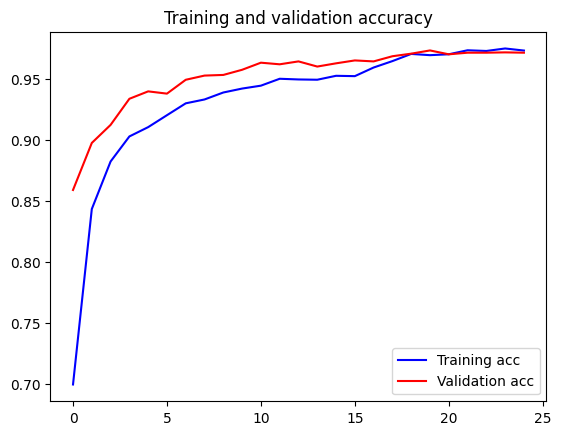

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

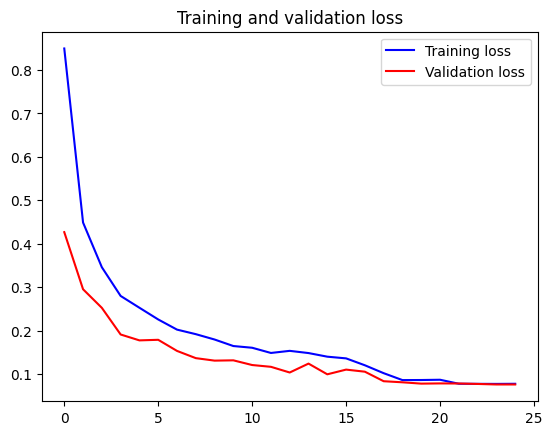

In [ ]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

60/60 [==============================] - 14s 230ms/step - loss: 0.0858 - accuracy: 0.9719
Test Loss: 0.0858
Test Accuracy: 0.9719


60/60 [==============================] - 17s 192ms/step


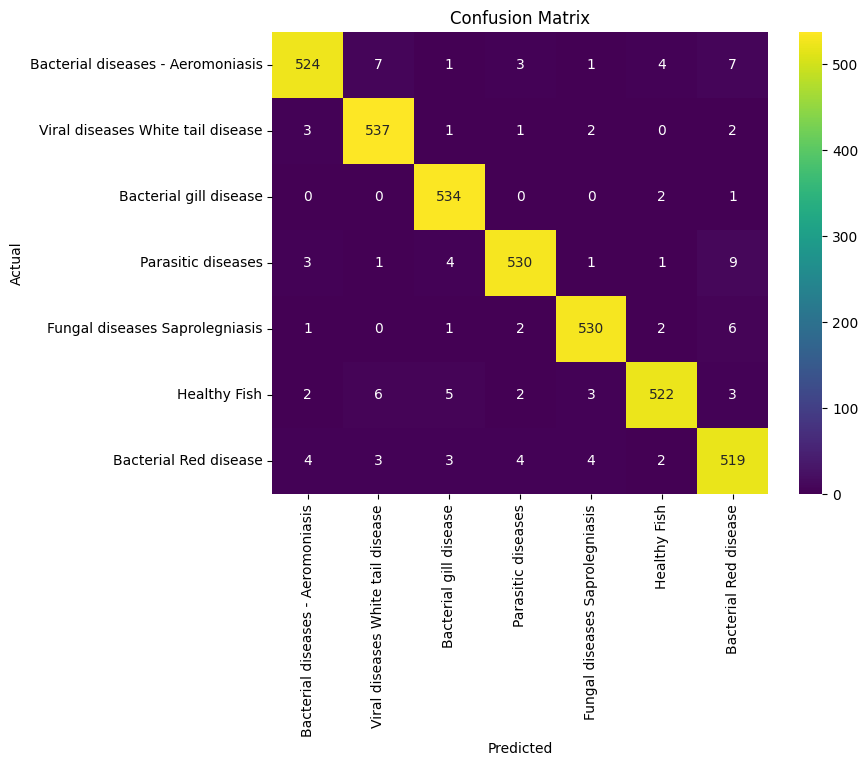

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='viridis',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

cm= confusion_mtx
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]


# Calculate metrics
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Precision: 0.9871323529411765
Recall: 0.9944444444444445
F1 Score: 0.9907749077490774
60/60 [==============================] - 12s 199ms/step


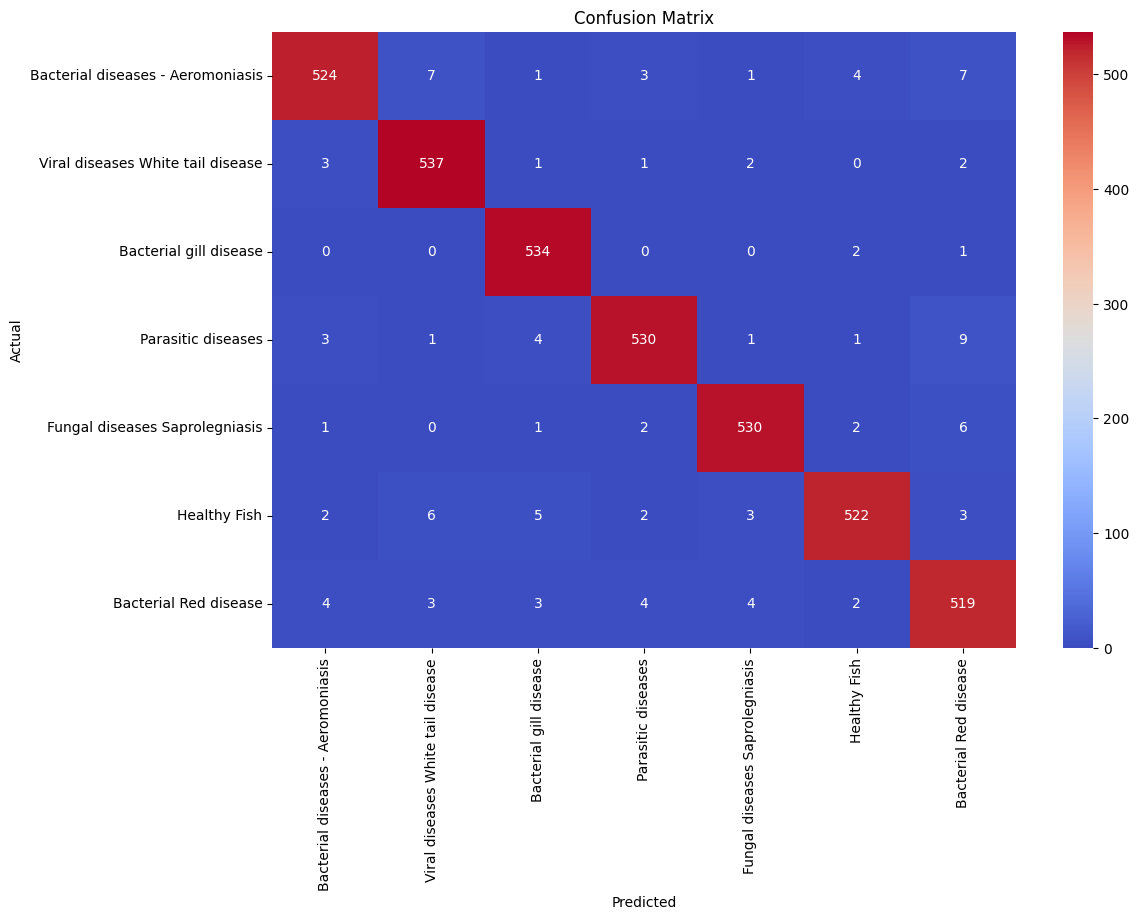

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



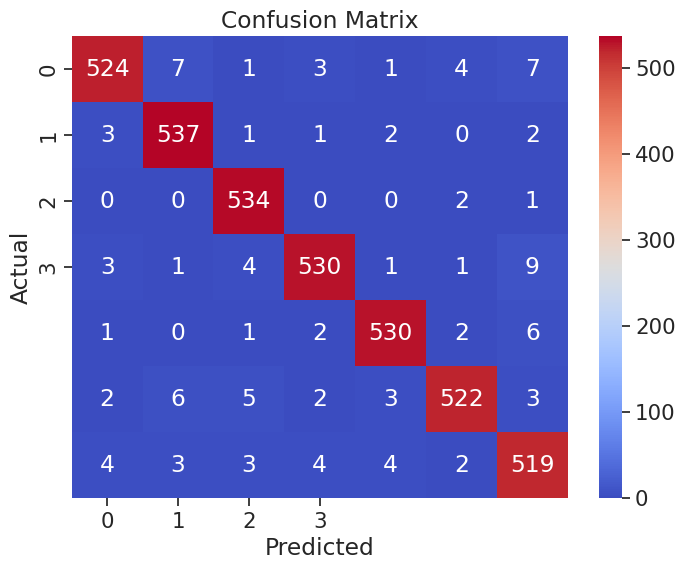

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


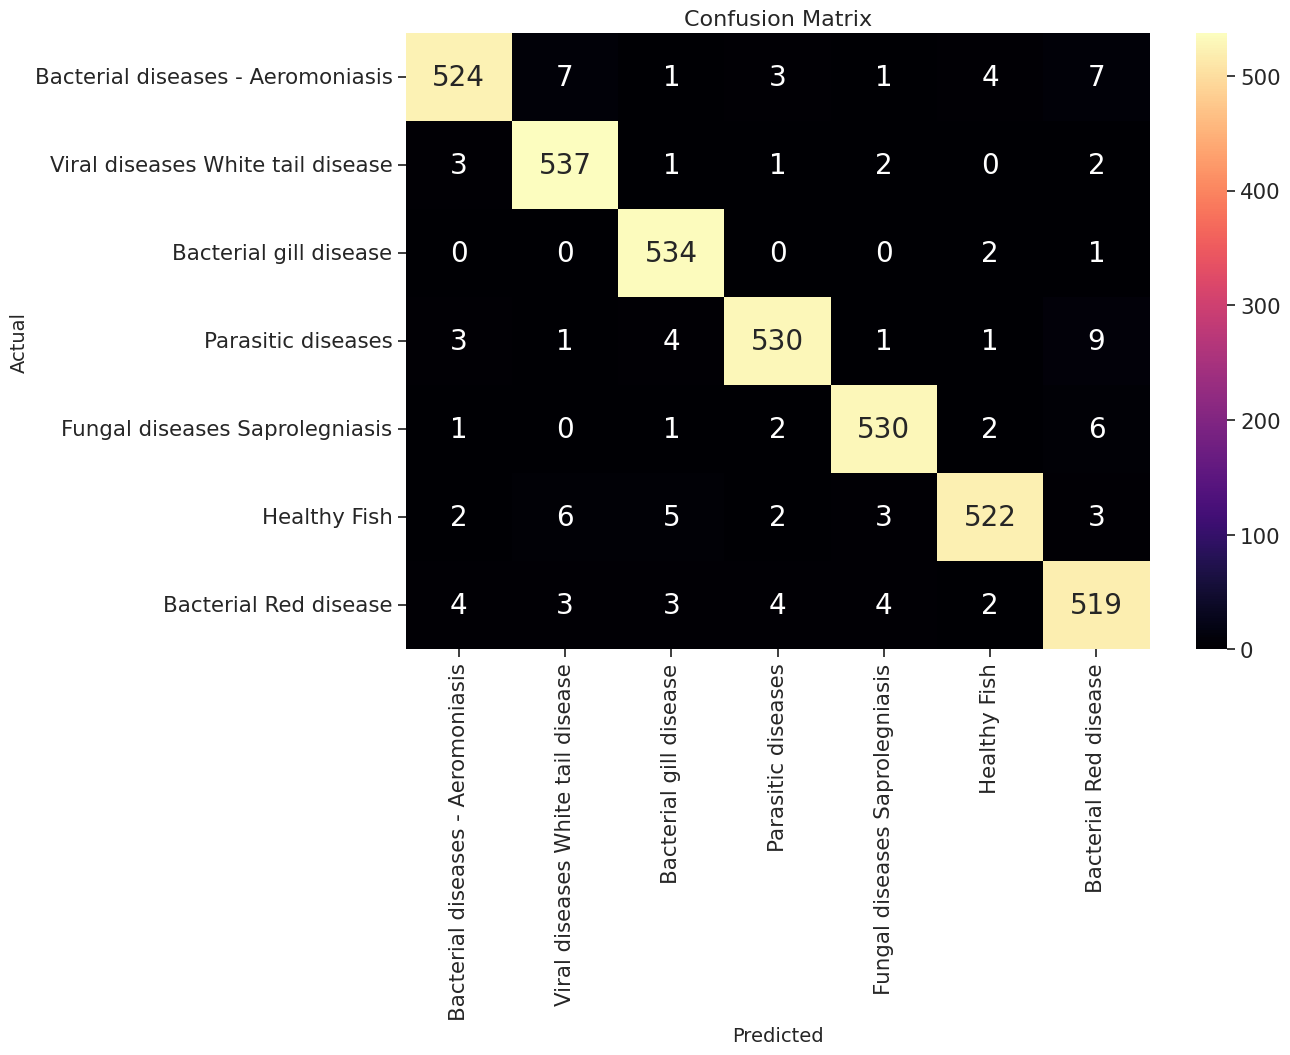

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


In [ ]:
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

In [ ]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       547
           1       0.97      0.98      0.98       546
           2       0.97      0.99      0.98       537
           3       0.98      0.97      0.97       549
           4       0.98      0.98      0.98       542
           5       0.98      0.96      0.97       543
           6       0.95      0.96      0.96       539

    accuracy                           0.97      3803
   macro avg       0.97      0.97      0.97      3803
weighted avg       0.97      0.97      0.97      3803



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming test_labels and predicted_labels are your actual and predicted labels
precision = precision_score(test_labels, predicted_labels, average='weighted')
recall = recall_score(test_labels, predicted_labels, average='weighted')
f1 = f1_score(test_labels, predicted_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.9719587388116395
Recall: 0.9718643176439653
F1 Score: 0.9718501102565003


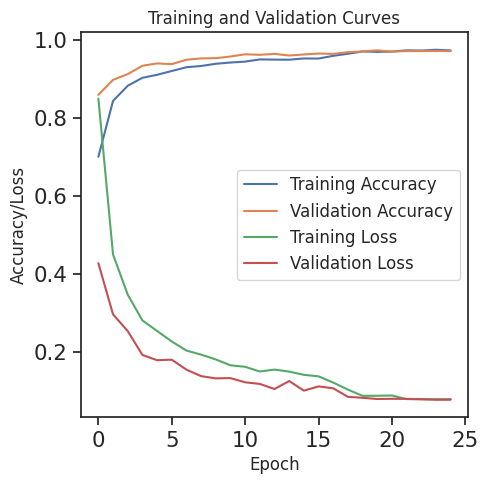

In [ ]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progess.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progess.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progess.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progess.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


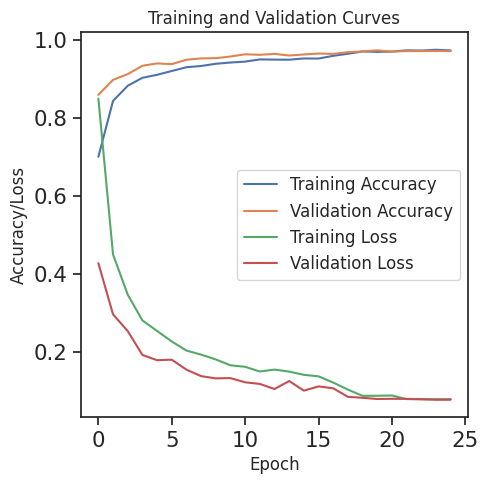

In [ ]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progess.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progess.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progess.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progess.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


In [ ]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       547
           1       0.97      0.98      0.98       546
           2       0.97      0.99      0.98       537
           3       0.98      0.97      0.97       549
           4       0.98      0.98      0.98       542
           5       0.98      0.96      0.97       543
           6       0.95      0.96      0.96       539

    accuracy                           0.97      3803
   macro avg       0.97      0.97      0.97      3803
weighted avg       0.97      0.97      0.97      3803



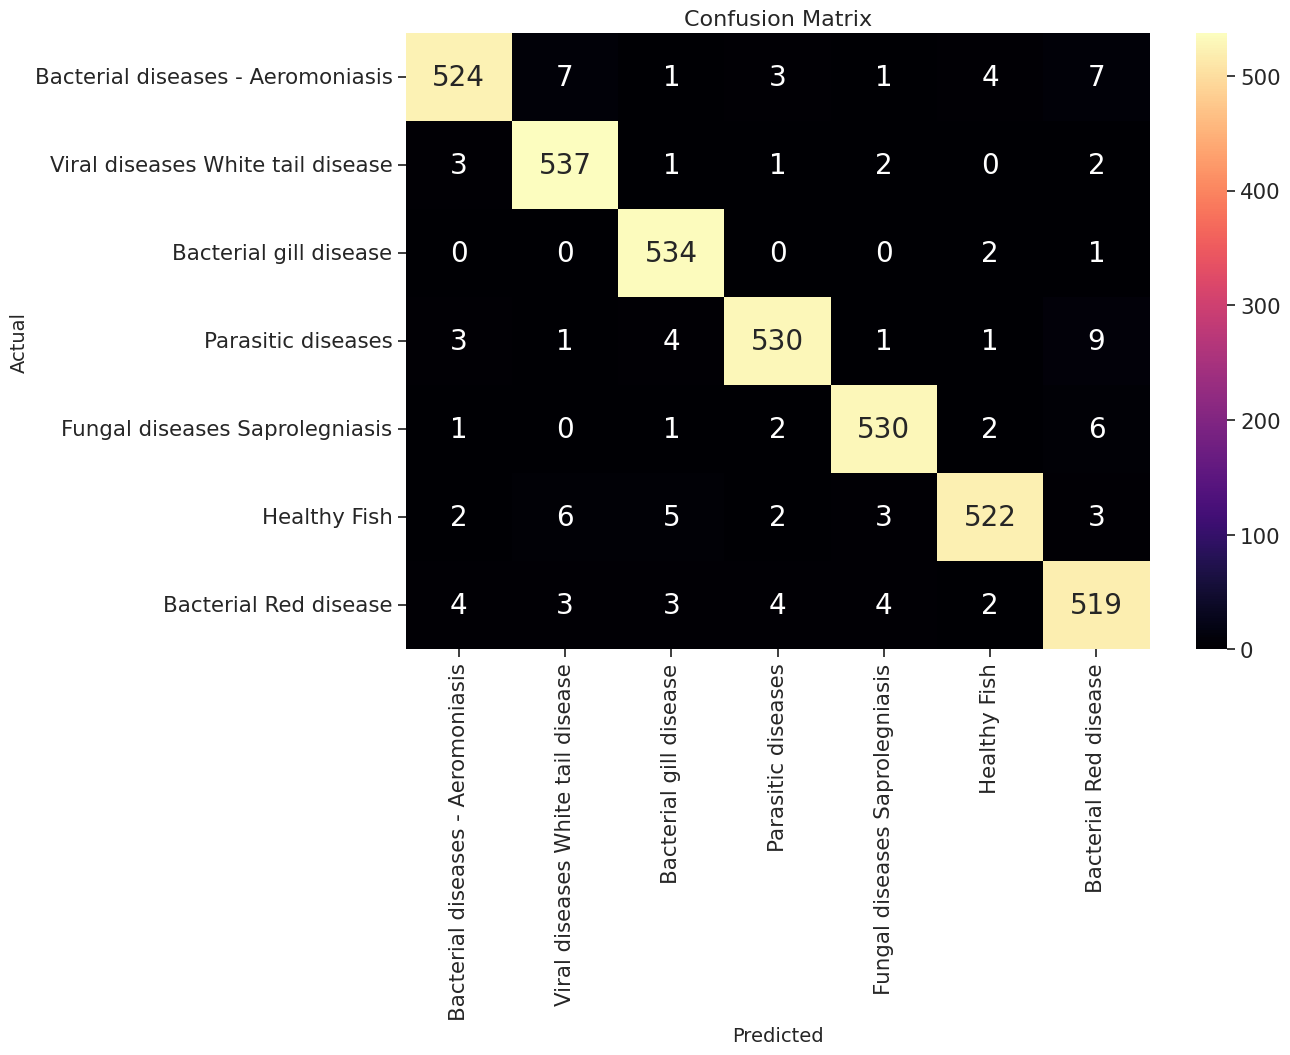

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='magma',
            xticklabels=classes, yticklabels=classes, annot_kws={"fontsize": 20})  # Adjust fontsize as needed
plt.xlabel('Predicted', fontsize=14)  # Adjust fontsize as needed
plt.ylabel('Actual', fontsize=14)  # Adjust fontsize as needed
plt.title('Confusion Matrix', fontsize=16)  # Adjust fontsize as needed
plt.savefig('images.pdf')
plt.show()


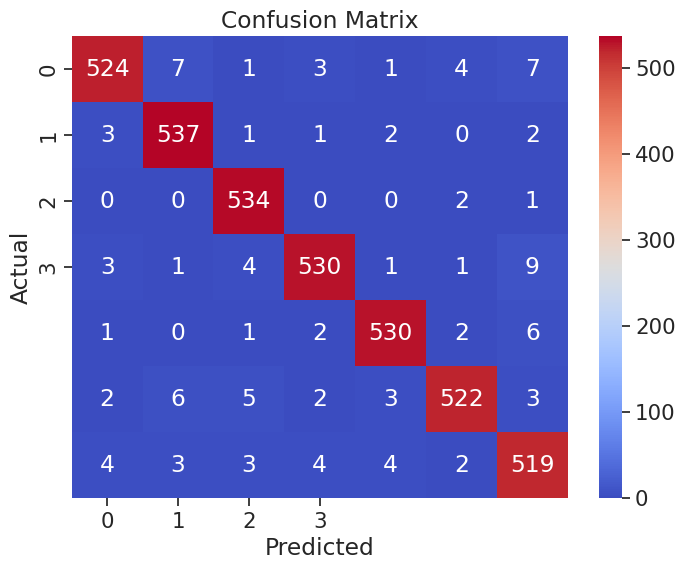

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = [0,1,2,3]
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


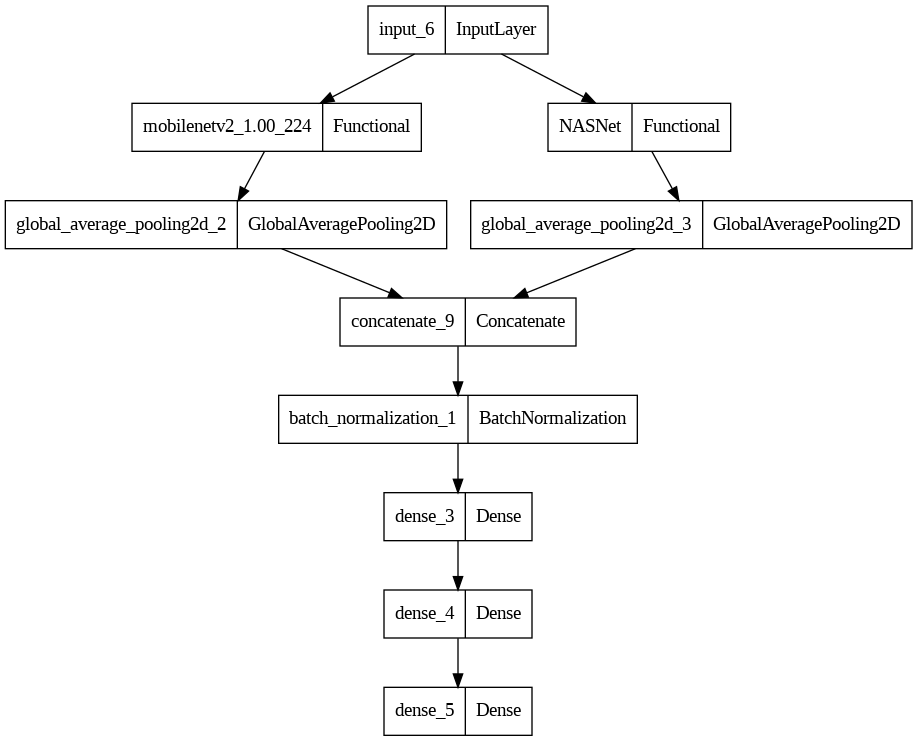

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model,'model.png')


60/60 [==============================] - 11s 189ms/step


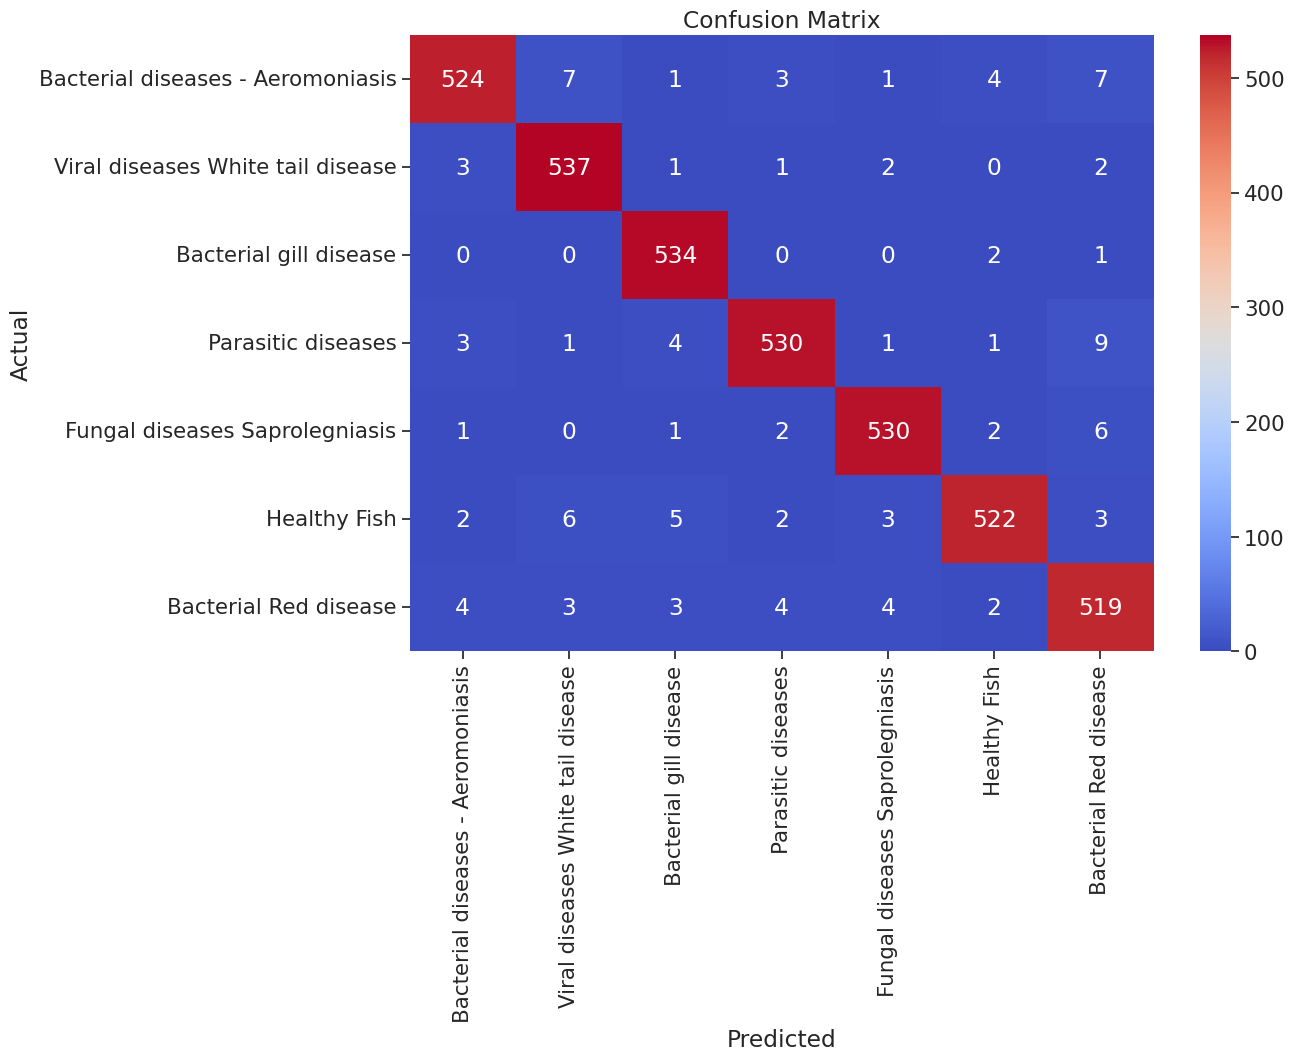

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming you have already trained and compiled your model
# train_ds is your training dataset

# Make predictions using the trained model
predictions = model.predict(test_generator)

# Convert predicted probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)

# Get the actual labels from the dataset

# Calculate the confusion matrix
confusion_mtx = confusion_matrix(test_labels, predicted_labels)
classes = class_folders


import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

classes = class_folders

# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



In [ ]:
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

In [ ]:
# prompt: print the precision recall and f1 score

from sklearn.metrics import classification_report
# Get the classification report
report = classification_report(test_labels, predicted_labels)

# Print the report
print(report)


              precision    recall  f1-score   support

           0       0.98      0.96      0.97       547
           1       0.97      0.98      0.98       546
           2       0.97      0.99      0.98       537
           3       0.98      0.97      0.97       549
           4       0.98      0.98      0.98       542
           5       0.98      0.96      0.97       543
           6       0.95      0.96      0.96       539

    accuracy                           0.97      3803
   macro avg       0.97      0.97      0.97      3803
weighted avg       0.97      0.97      0.97      3803



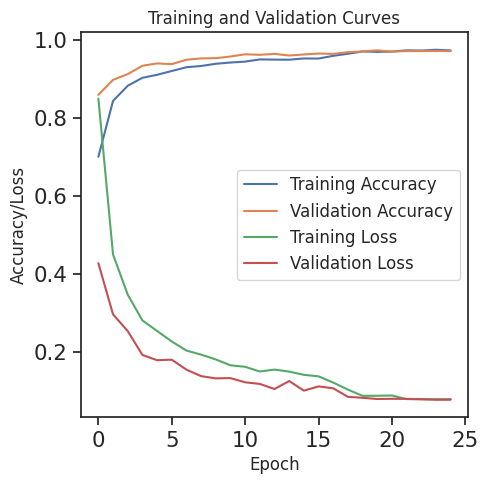

In [ ]:
# prompt: plot the trainig and validation curves using seaborn

import matplotlib.pyplot as plt
# Plot training and validation curves using Seaborn
import seaborn as sns

# Create a figure and axes
fig, ax = plt.subplots(figsize=(5, 5))

# Plot training and validation accuracy
sns.lineplot(x=progess.epoch, y=acc, label='Training Accuracy', ax=ax)
sns.lineplot(x=progess.epoch, y=val_acc, label='Validation Accuracy', ax=ax)

# Plot training and validation loss
sns.lineplot(x=progess.epoch, y=loss, label='Training Loss', ax=ax)
sns.lineplot(x=progess.epoch, y=val_loss, label='Validation Loss', ax=ax)

# Set labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy/Loss', fontsize=12)
ax.set_title('Training and Validation Curves', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Display the plot
plt.show()


60/60 [==============================] - 11s 187ms/step


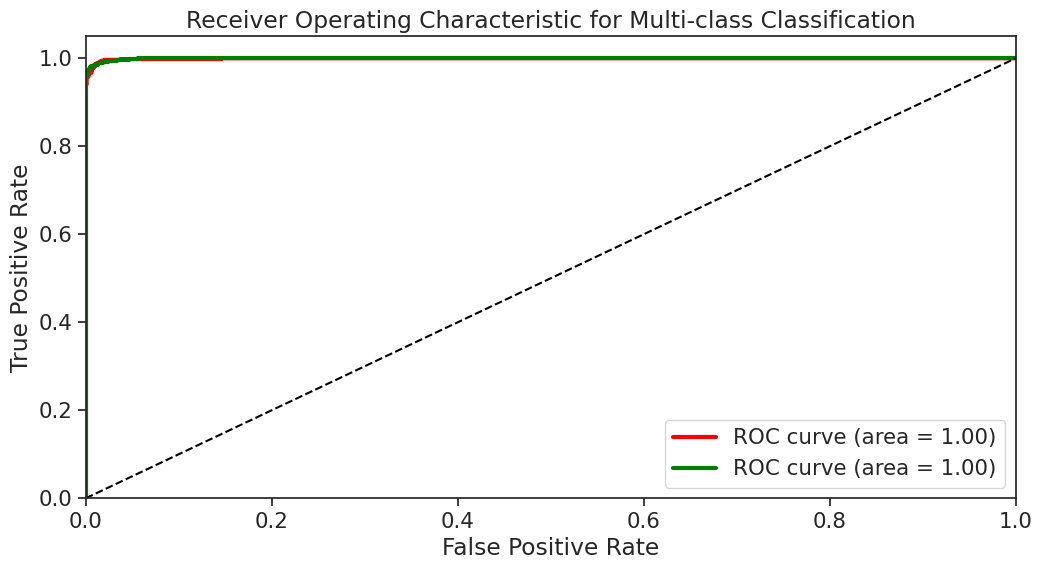

AUC scores:
Class 1: 0.9993141862882451
Class 2: 0.9994672797939169


In [ ]:
# prompt: ROC Curve display for deep learning

# Get predicted probabilities for each class
predictions = model.predict(val_generator)

# Get the actual labels
test_labels = np.array(val_generator.labels)

# Binarize the test labels
test_labels_bin = keras.utils.to_categorical(test_labels)

# Calculate ROC curves and AUC for each class
fpr = {}
tpr = {}
auc_scores = {}

n_classes = 2  # Adjust this to your number of classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], predictions[:, i])
    auc_scores[i] = auc(fpr[i], tpr[i])

# Plot the ROC curves
plt.figure(figsize=(12, 6))


lw = 3
colors = ['red', 'green', 'blue', 'orange']  # Adjust colors for each class

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw,
             label='ROC curve (area = %0.2f)' % auc_scores[i])

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Print AUC scores
print('AUC scores:')
for i, score in auc_scores.items():
    print(f'Class {i+1}: {score}')


In [ ]:
# prompt: precison, recall and f1 score using sk learn

from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already evaluated your model and have the following variables:
# test_generator.classes: True labels
# model.predict(test_generator): Predicted probabilities
# classes: List of class names

# Calculate precision, recall, and F1-score for each class
precision = precision_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
recall = recall_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))
f1 = f1_score(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), average=None, labels=range(len(classes)))

# Print the results
for i, cls in enumerate(classes):
    print(f"Class {cls}:")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()


60/60 [==============================] - 12s 196ms/step
Class Bacterial diseases - Aeromoniasis:
Precision: 0.9758
Recall: 0.9580
F1-score: 0.9668

Class Viral diseases White tail disease:
Precision: 0.9693
Recall: 0.9835
F1-score: 0.9764

Class Bacterial gill disease:
Precision: 0.9727
Recall: 0.9944
F1-score: 0.9834

Class Parasitic diseases:
Precision: 0.9779
Recall: 0.9654
F1-score: 0.9716

Class Fungal diseases Saprolegniasis:
Precision: 0.9797
Recall: 0.9779
F1-score: 0.9788

Class Healthy Fish:
Precision: 0.9794
Recall: 0.9613
F1-score: 0.9703

Class Bacterial Red disease:
Precision: 0.9488
Recall: 0.9629
F1-score: 0.9558



In [ ]:
# prompt: print the classification report

print(classification_report(test_generator.classes, np.argmax(model.predict(test_generator), axis=1), target_names=classes))


60/60 [==============================] - 12s 197ms/step
                                   precision    recall  f1-score   support

Bacterial diseases - Aeromoniasis       0.98      0.96      0.97       547
Viral diseases White tail disease       0.97      0.98      0.98       546
           Bacterial gill disease       0.97      0.99      0.98       537
               Parasitic diseases       0.98      0.97      0.97       549
   Fungal diseases Saprolegniasis       0.98      0.98      0.98       542
                     Healthy Fish       0.98      0.96      0.97       543
            Bacterial Red disease       0.95      0.96      0.96       539

                         accuracy                           0.97      3803
                        macro avg       0.97      0.97      0.97      3803
                     weighted avg       0.97      0.97      0.97      3803



In [ ]:
model.save('Fish7p.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


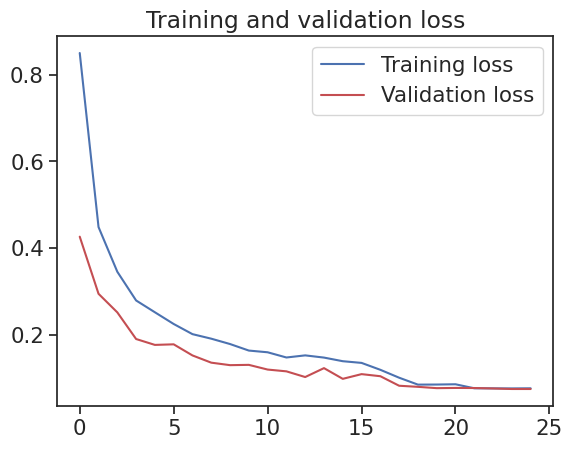

In [ ]:
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

<Figure size 640x480 with 0 Axes>

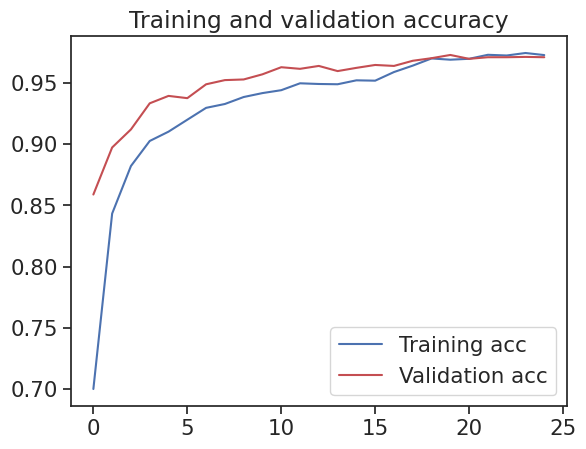

<Figure size 640x480 with 0 Axes>

In [ ]:
acc = progess.history['accuracy']
val_acc = progess.history['val_accuracy']
loss = progess.history['loss']
val_loss = progess.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

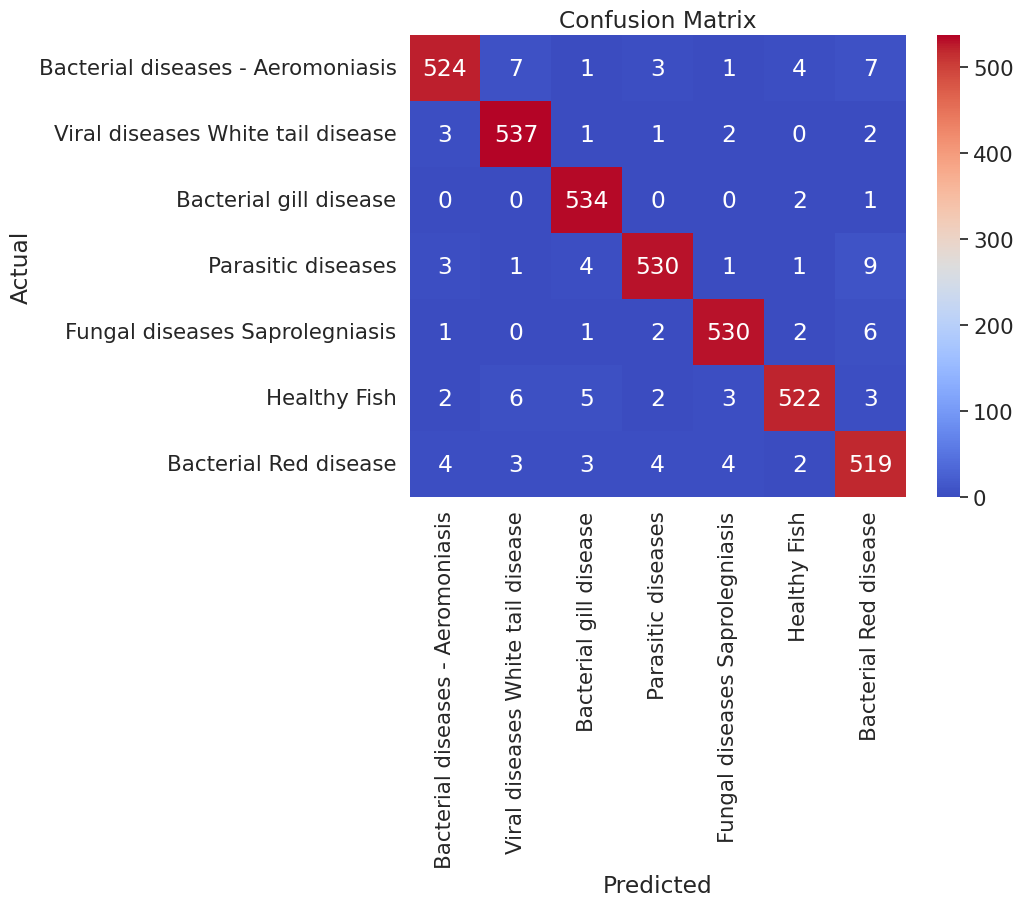

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming you have already trained and compiled your model
# train_ds is your training dataset
classes = class_folders
# Create a Seaborn heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.4)  # Set the font scale
#sns.set_style("ticks", {"font.family": "Times New Roman"})  # Set the font family to Times New Roman
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=classes, yticklabels=classes)  # Replace 'classes' with your class labels
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


60/60 [==============================] - 11s 189ms/step


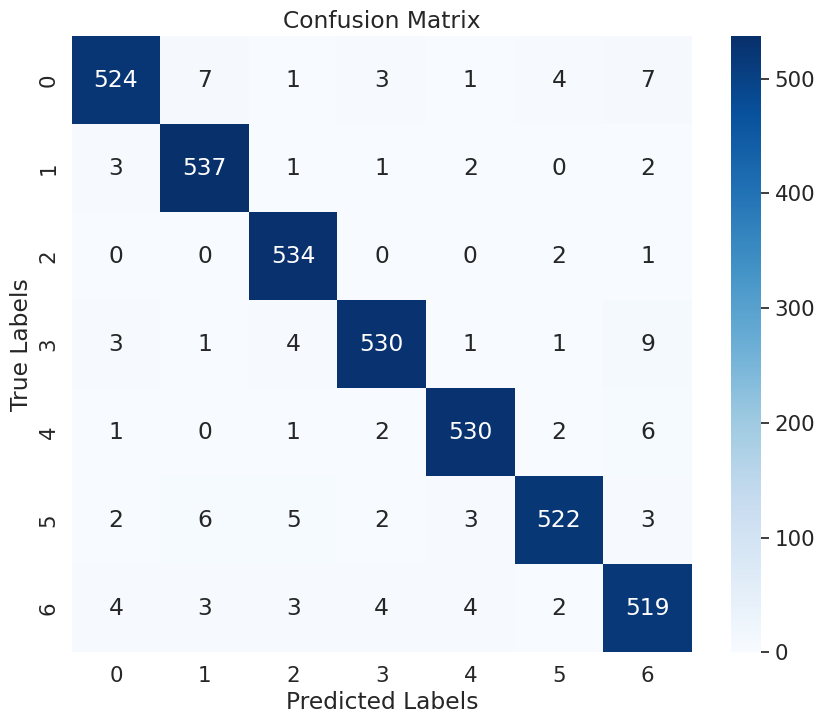

In [ ]:
# prompt: give code for confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Get the predicted labels for the test data
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)

# Get the true labels for the test data
true_labels = test_generator.classes

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


1/1 [==============================] - 1s 741ms/step


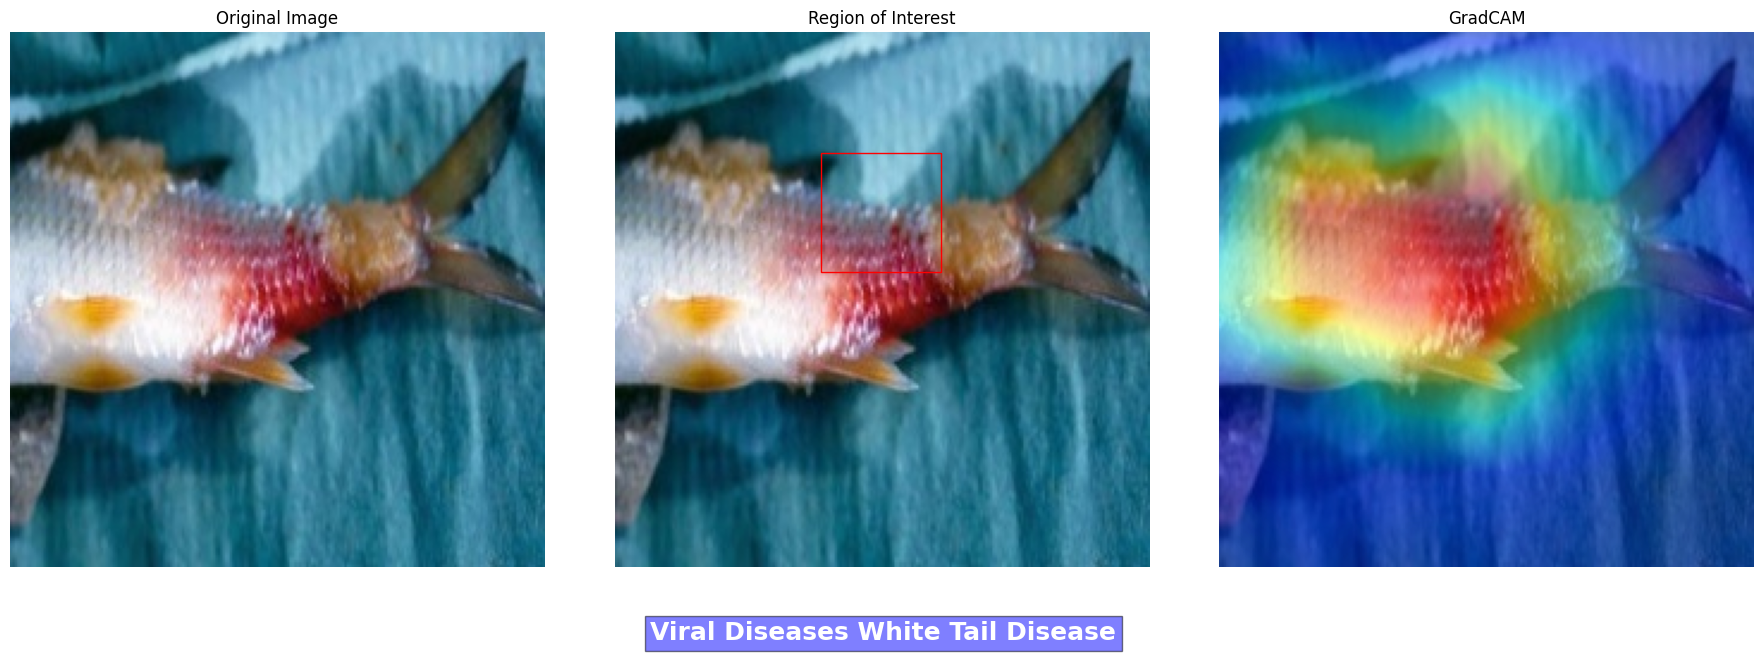

In [85]:
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.feature import peak_local_max
import tensorflow as tf
import scipy.ndimage

# Load MobileNetV2 model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

# Load the MobileNetV2 model pre-trained on ImageNet
model = MobileNetV2(weights='imagenet')

def grad_cam_plus_plus(input_model, image, cls, layer_name):
    """
    Grad-CAM++ method for visualizing input saliency.
    """
    last_conv_layer = input_model.get_layer(layer_name)
    conv_output = last_conv_layer.output

    # Define a function that computes the model output given an input image
    model_with_output = tf.keras.Model(inputs=input_model.inputs, outputs=[conv_output, input_model.output])

    with tf.GradientTape() as tape:
        conv_output, predictions = model_with_output(image)
        output_class = predictions[0, cls]

    # Compute gradients of the output class with respect to the convolutional output
    grads = tape.gradient(output_class, conv_output)

    # Compute first-order and second-order gradients
    first_grads = tf.exp(output_class) * grads
    second_grads = tf.exp(output_class) * grads * grads

    # Compute weights and alphas
    weights = tf.reduce_mean(grads, axis=(0, 1))
    alpha_num = first_grads
    alpha_denom = first_grads * 2.0 + second_grads * conv_output
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom) * 1e-10)
    alphas = alpha_num / alpha_denom
    weights_alpha = tf.maximum(weights, 0.0)

    # Compute Grad-CAM++ heatmap
    grad_cam = tf.reduce_sum(weights_alpha * conv_output, axis=2)
    grad_cam = tf.maximum(grad_cam, 0)
    heatmap = grad_cam / tf.reduce_max(grad_cam)

    return heatmap.numpy()

# Read an image
img = cv2.imread('/content/Freshwater Fish Disease Aquaculture in south asia/Train/Viral diseases White tail disease/Viral diseases White tail disease (1).jpg', 1)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = Image.fromarray(img, 'RGB')
img = img.resize((224, 224))  # MobileNetV2 input size
img = np.array(img)

img_tensor = np.expand_dims(img, axis=0)
preprocessed_img = preprocess_input(img_tensor)

# Output both predictions (last layer) and out_relu (last convolutional layer)
model_output = model.get_layer('out_relu').output
model = tf.keras.models.Model(inputs=model.input, outputs=(model_output, model.output))

# Get the predictions and the output of last conv. layer.
last_conv_output, pred_vec = model.predict(preprocessed_img)
# Last conv. output for the image
last_conv_output = np.squeeze(last_conv_output)

# spline interpolation to resize each filtered image to size of original image
h = int(img.shape[0] / last_conv_output.shape[0])
w = int(img.shape[1] / last_conv_output.shape[1])
upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)

# Get the weights from the last layer for the prediction class
last_layer_weights_for_pred = model.layers[-1].get_weights()[0][:, np.argmax(pred_vec)]

# Reshape upsampled_last_conv_output to match the second dimension of last_layer_weights_for_pred
upsampled_last_conv_output_flat = upsampled_last_conv_output.reshape((-1, 1280))

# Perform dot product
heat_map = np.dot(upsampled_last_conv_output_flat, last_layer_weights_for_pred)

# Reshape heat_map back to original image size
heat_map = heat_map.reshape((224, 224))

# Find peak coordinates
peak_coords = peak_local_max(heat_map, num_peaks=10, threshold_rel=0.4, min_distance=20)

# Plot original image with heatmap overlaid.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Display the original image
axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Overlay the peak coordinates on the original image
axes[1].imshow(img)
for i in range(0, peak_coords.shape[0]):
    y = peak_coords[i, 0]
    x = peak_coords[i, 1]
    axes[1].add_patch(Rectangle((x - 25, y - 25), 50, 50, linewidth=1, edgecolor='r', facecolor='none'))
axes[1].set_title('Region of Interest')
axes[1].text(img.shape[1] / 2, img.shape[0] + 30, 'Viral Diseases White Tail Disease', color='white', fontsize=18, fontweight='bold', ha='center', bbox=dict(facecolor='blue', alpha=0.5))
axes[1].axis('off')

# Overlay the heatmap on the original image
axes[2].imshow(img)
axes[2].imshow(heat_map, cmap='jet', alpha=0.4)
axes[2].set_title('GradCAM')
axes[2].axis('off')

plt.tight_layout()
plt.show()


gpu
system ram 3.6
gpu ram 4.1
disk 26.9